<div style="border:3px solid #E50914; border-radius:14px; padding:20px; background:linear-gradient(135deg, #141414, #1f1f1f); color:white; font-family:Arial, Helvetica, sans-serif;">

<p align="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/0/08/Netflix_2015_logo.svg" width="180"/>
</p>

<h1 align="center" style="color:#E50914;">
🎬 Unlocking Insights from Netflix Data
</h1>

<h3 align="center">
A SQL-Powered Exploratory Data Analysis Journey
</h3>

<hr style="border:1px solid #E50914;">

<p style="font-size:16px;">
This notebook demonstrates <b>SQL-powered Exploratory Data Analysis (EDA)</b> on real Netflix datasets using 
<b>SQLite</b>, <b>Pandas</b>, and <b>Python-based visualizations</b>.  
The project simulates a real-world OTT analytics workflow, focusing on data modeling, joins, and business insights.
</p>

### 📂 Data Tables Used
- 🎭 **Titles** – Netflix Movies & TV Shows metadata  
- 📊 **Viewership** – Viewing hours and popularity metrics  
- 🌍 **Subscriptions** – Country-wise subscription & revenue data  
- ⭐ **Reviews** – User ratings and engagement information  

### ✨ Key Analysis Features
- 📈 Content growth trends over the years  
- 🎞️ Movie vs TV Show distribution  
- 🌎 Country-wise subscription analysis  
- 🔍 Popular content based on viewership  
- ⭐ Rating & user engagement insights  
- ⏳ Release year & duration patterns  

<hr style="border:1px solid #E50914;">

<p align="center" style="font-style:italic;">
Grab some popcorn 🍿 — let’s explore Netflix data and stream powerful insights!
</p>

</div>


# 📑 Table of Contents
---

## 🎬 1. Project Overview
- Business Context & Motivation
- Problem Statement
- Objectives of the Analysis
- Tools & Technologies Used

## 🧱 2. Data Architecture & Modeling
- Dataset Overview
- Relational Data Model
- Table Relationships & Keys
- Data Dictionary

## 🗄️ 3. Database Schema Design
- Titles Table (Movies & TV Shows Metadata)
- Viewership Table (Popularity & Engagement Metrics)
- Subscriptions Table (Country-wise Subscriptions & Revenue)
- Reviews Table (User Ratings & Feedback)
- Schema Design Rationale

## 🧹 4. Data Cleaning & Quality Checks
- Missing Value Analysis
- Trimming Whitespaces & Text Standardization
- Handling Inconsistent Ratings & Durations
- Validating Foreign Key Relationships
- Final Cleaned Tables

## 🔎 5. Exploratory Data Analysis (EDA)
- Movies vs TV Shows Distribution
- Content Release Trends Over Time
- Rating Distribution & User Engagement
- Viewership Analysis
- Country-wise Subscription Trends

## 🧠 6. Advanced SQL Analysis
- Multi-table JOIN Analysis
- Subqueries & Common Table Expressions (CTEs)
- Window Functions (RANK, DENSE_RANK, ROW_NUMBER)
- Top-N Content Analysis
- Time-based Trend Analysis

## 🛠️ 7. Feature Engineering
- Content Age Buckets
- Popularity Categories (Based on Viewership)
- Rating Segmentation
- Analytical Columns for Business Insights

## 📊 8. Visual Analytics & Storytelling
- Content Growth Over the Years
- Viewership vs Ratings Analysis
- Subscription Distribution by Country
- Top Performing Titles Visualization
- Engagement Trend Charts

## 💡 9. Business Insights & Recommendations
- Content Strategy Insights
- High-Engagement Content Characteristics
- Regional Market Opportunities
- Viewer Preference Patterns

## ✅ 10. Key Takeaways
- Summary of Key Findings
- Data-driven Conclusions
- Business Impact & Learnings

## 📎 11. Appendix
- SQL Query Repository
- Python Utility Functions
- Assumptions & Limitations


## 🧱 2. Database Design & Schema

In this section, we design the **relational database schema** for the Netflix Content Analysis project.

The schema is built using **real-world OTT analytics principles**, ensuring:
- Proper normalization
- Clear primary and foreign key relationships
- Efficient JOIN operations for analytical queries
- Scalability for business-driven insights

### 📐 Tables Included
- **titles** – Core metadata for Netflix Movies & TV Shows  
- **viewership** – Popularity metrics such as total hours viewed and audience reach  
- **subscriptions** – Country-wise Netflix subscription and revenue data  
- **reviews** – User ratings and engagement information for titles  

> This schema enables advanced SQL analysis such as content performance evaluation, user engagement trends, country-wise market insights, and data-driven content strategy decisions.


In [ ]:
-- Titles Table
CREATE TABLE titles (
    show_id        VARCHAR(20) PRIMARY KEY,
    title          VARCHAR(200),
    type           VARCHAR(20),      -- Movie / TV Show
    director       VARCHAR(200),
    cast           TEXT,
    country        VARCHAR(100),
    date_added     DATE,
    release_year   INT,
    rating         VARCHAR(20),
    duration       VARCHAR(50),
    listed_in      TEXT,
    description    TEXT
);
-- Viewership Table
CREATE TABLE viewership (
    view_id               INTEGER PRIMARY KEY AUTOINCREMENT,
    show_id               VARCHAR(20),
    total_hours_viewed    REAL,
    views_millions        REAL,
    FOREIGN KEY (show_id) REFERENCES titles(show_id)
);
-- Subscriptions Table
CREATE TABLE subscriptions (
    subscription_id            INTEGER PRIMARY KEY AUTOINCREMENT,
    country                    VARCHAR(100),
    year                       INT,
    total_subscriptions_millions REAL,
    revenue_usd_billions       REAL
);
-- Reviews Table
CREATE TABLE reviews (
    review_id      INTEGER PRIMARY KEY AUTOINCREMENT,
    show_id        VARCHAR(20),
    user_rating    REAL,
    review_count   INT,
    FOREIGN KEY (show_id) REFERENCES titles(show_id)
);


## 🐍 2. Python Setup and EDA Pipeline

In this section, we set up the **Python environment** and establish a connection to the  
**MySQL database** that stores our Netflix datasets.

This pipeline enables:
- Seamless SQL–Python integration using **SQLAlchemy**
- Data extraction into **Pandas DataFrames**
- Exploratory Data Analysis (EDA) using **Pandas, Matplotlib, and Seaborn**

### 🔧 Tools & Libraries Used
- **SQLAlchemy** – Database connectivity
- **Pandas** – Data manipulation & analysis
- **Matplotlib & Seaborn** – Data visualization

### 📂 Datasets Used (ONLY Project Tables)
- **titles** – Movies & TV Shows metadata
- **viewership** – Watch hours & popularity metrics
- **subscriptions** – User subscription details
- **reviews** – Ratings & user feedback


In [1]:
# ===============================
# MySQL → Pandas Connection Setup
# ===============================

from sqlalchemy import create_engine
from urllib.parse import quote_plus
import pandas as pd

# Database credentials
db_user = 'root'
db_password = quote_plus("Mridul@123")   # IMPORTANT: encoded password
db_host = '127.0.0.1'
db_port = 3306
db_name = 'github_db'

# Create SQLAlchemy engine
engine = create_engine(
    f"mysql+pymysql://{db_user}:{db_password}@{db_host}:{db_port}/{db_name}"
)



## 🔁 Exploratory Data Analysis (EDA) Pipeline

This project follows a **structured EDA pipeline** using **MySQL, SQLAlchemy, Pandas, and Python visualizations** to extract meaningful insights from Netflix data.

---

### 🗃️ 1. Data Collection
Data is sourced directly from a **MySQL database** containing multiple Netflix-related tables.

**Methods used:**
- Reading SQL tables into Pandas DataFrames
- Verifying data integrity after ingestion




In [2]:
# load titles table
netflix_titles = pd.read_sql("SELECT * FROM netflix_titles", engine)
netflix_titles

,show_id,title,type,release_year,genre,rating,director,country,language,date_added,imdb_score,budget_millions,age_certification
0,464237c8-d,War forward personal,TV Show,2021,Comedy,TV-MA,James Carpenter,Japan,Spanish,2019-03-20,3.7,108.11,Kids
1,ef1d668f-9,Require hundred recognize,Movie,1981,Documentary,TV-MA,Cassandra Goodman,Japan,Japanese,2018-07-21,3.2,265.63,Kids
2,61e8d17c-4,Adult exactly tough,TV Show,2002,Comedy,G,Kathleen Rodriguez,Japan,Korean,2023-07-24,8.6,206.21,All
3,43e4d2cc-d,Arm war,Movie,1996,Horror,PG-13,Jessica Foster,United Kingdom,English,2022-01-17,7.6,228.62,Kids
4,050cb3d7-4,Beat view,Movie,1995,Comedy,TV-14,Kristin Ramirez,Canada,English,2023-07-23,4.7,272.07,All
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19071,bd617de7-f,Miss may lawyer section,Movie,2001,Horror,PG,Erin Olson,Japan,French,2020-10-21,6.9,111.74,Adult
19072,fadd6027-4,At stay,Movie,1992,Action,PG-13,Elizabeth Mendez,Japan,Korean,2019-09-06,3.1,209.34,Kids
19073,f382b395-0,Why look term,Movie,2003,Drama,TV-MA,Melissa Terry,South Korea,Korean,2018-08-13,9.9,98.61,Kids
19074,b5e4f131-d,Letter take,TV Show,1994,Thriller,g,Taylor Suarez,United Kingdom,English,2019-04-29,6.9,274.71,Teen


In [24]:
# load reviews tables
netflix_reviews = pd.read_sql("SELECT * FROM netflix_reviews", engine)
netflix_reviews

,review_id,show_id,rating,sentiment,review_text,review_date
0,R1,464237c8-d,2.2,Positive,Product worry language everybody someone guess...,2022-05-16
1,R2,ef1d668f-9,4.8,Positive,May tonight throw itself team task performance...,2023-11-23
2,R3,61e8d17c-4,3.9,Negative,Bar lot argue notice clear certain line develo...,2025-03-10
3,R4,,2.3,Neutral,Keep sure mission modern population doctor siz...,2022-09-01
4,R5,050cb3d7-4,2.5,,Staff ability human society again many includi...,2022-09-01
...,...,...,...,...,...,...
19707,R19996,bd617de7-f,3.8,Neutral,Method mind responsibility bag central individ...,2024-01-16
19708,R19997,fadd6027-4,2.5,Negative,Bank always can dream drug easy attention movi...,2025-09-05
19709,R19998,f382b395-0,1.1,Neutral,Technology without take life set hospital whet...,2023-04-12
19710,R19999,b5e4f131-d,3.6,Negative,Appear shoulder attention stop participant tes...,2025-11-23


In [26]:
# load subscriptions tables
netflix_subscriptions = pd.read_sql("SELECT * FROM netflix_subscriptions", engine)
netflix_subscriptions

,subscription_id,show_id,subscription_type,subscription_price,billing_cycle,start_date
0,S1,464237c8-d,Standard,4.08,Yearly,2025-04-06
1,S2,ef1d668f-9,Basic,23.16,Monthly,2021-08-16
2,S3,61e8d17c-4,Standard,8.25,Yearly,2022-05-15
3,S4,43e4d2cc-d,Premium,16.06,Yearly,2023-04-20
4,S5,050cb3d7-4,Standard,12.48,Monthly,2025-11-17
...,...,...,...,...,...,...
19698,S19996,bd617de7-f,Premium,19.88,Yearly,2023-09-23
19699,S19997,fadd6027-4,Premium,11.59,Monthly,2022-12-15
19700,S19998,f382b395-0,Premium,15.20,Monthly,2025-10-30
19701,S19999,b5e4f131-d,Basic,15.28,Yearly,2021-10-06


In [25]:
# load viewership tables
netflix_viewership = pd.read_sql("SELECT * FROM netflix_viewership", engine)
netflix_viewership

,view_id,show_id,views_millions,watch_hours_millions,region,device_type,completion_rate
0,V1,464237c8-d,115.57,548.46,Europe,TV,79.96
1,V2,ef1d668f-9,,237.16,Europe,Laptop,71.75
2,V3,61e8d17c-4,194.33,53.11,South America,Laptop,46.23
3,V4,43e4d2cc-d,65.57,401.37,North America,Tablet,68.27
4,V5,050cb3d7-4,131.04,538.07,North America,Tablet,58.06
...,...,...,...,...,...,...,...
19445,V19996,bd617de7-f,133.33,559.52,South America,Tablet,71.79
19446,V19997,fadd6027-4,70.82,233.70,South America,Mobile,91.53
19447,V19998,f382b395-0,14.09,338.20,Asia,TV,83.68
19448,V19999,b5e4f131-d,57.49,119.40,Europe,TV,38.01


## 🧼 2. Data Cleaning

In this stage, the raw Netflix dataset is cleaned to ensure accuracy, consistency, and readiness for analysis.

### Key Data Cleaning Steps:
- **Handling Missing Values (NULL / NaN):**
  - Identified missing values in columns such as director, cast, country, and rating.
  - Replaced missing categorical values with appropriate placeholders like *"Unknown"* where required.
  - Retained missing values where they carry analytical significance.

- **Fixing Data Types:**
  - Converted date-related columns such as `date_added` from string format to proper date format.
  - Ensured numerical columns like `release_year` are stored in the correct data type.

- **Removing Duplicates:**
  - Checked for duplicate records based on unique identifiers (e.g., `show_id`).
  - Removed redundant rows to prevent double counting and ensure data integrity.

All data cleaning operations are performed and documented in the notebook:
**`Data_Cleaning_Analysis.ipynb`**

---

## 🧠 3. Feature Engineering

Feature engineering is applied to enhance the dataset by creating meaningful variables that support deeper analysis.

### Feature Engineering Activities:
- Extracted new features such as:
  - Year and month from `date_added`
  - Content duration categories (e.g., short movies, long movies, multi-season shows)
- Grouped and transformed categorical variables like genres and countries for trend analysis.
- Prepared features suitable for aggregation, filtering, and comparative analysis.

---

## ✅ 4. Post-Cleaning Validation

After cleaning and feature engineering, validation checks are performed to ensure data quality.

### Validation Checks:
- Verified that no unintended NULL values remain after cleaning.
- Confirmed correct data formats for date and numerical columns.
- Ensured newly created features are accurate and consistent across all records.

---

## 📊 5. Feature-wise and Comparative Analysis

This phase focuses on understanding patterns, trends, and distributions across different features.

### Analysis Performed:
- Analyzed distributions of movies and TV shows across years.
- Studied genre-wise and country-wise content availability.
- Compared content characteristics using groupings and aggregations.
- Identified trends in Netflix content growth and production focus over time.

These analyses form the foundation for insights and visualizations in the Exploratory Data Analysis (EDA) stage.


## 📊 All Tables After Data Cleaning

After performing the data cleaning steps, the following tables are now clean and ready for analysis:

1. **`netflix_titles`** – Duplicates removed, null values handled, column names corrected, and data formatted.  
2. **`Netflix_Subscription`** – Duplicates removed, null values handled, start date converted to datetime, column names standardized, and specific columns corrected.  
3. **`Netflix_Reviews`** – Duplicates removed, missing values handled, column names standardized, dates converted to datetime, and names corrected.  
4. **`Netflix_Viewership`** – Extra spaces removed from column names, missing values handled, duplicates removed, and data formatted consistently.

All tables are now clean and ready for further analysis.

In [2]:
# Load Titles Table
query="""
SELECT * 
FROM netflix_titles_clean"""
titles_df=pd.read_sql(query,engine)
titles_df

,show_id,title,type,release_year,genre,rating,director,country,language,date_added,imdb_score,budget_millions,age_certification
0,464237c8-d,War forward personal,TV Show,2021,Comedy,TV-MA,James Carpenter,Japan,Spanish,2019-03-20,3.7,108.11,Kids
1,ef1d668f-9,Require hundred recognize,Movie,1981,Documentary,TV-MA,Cassandra Goodman,Japan,Japanese,2018-07-21,3.2,265.63,Kids
2,61e8d17c-4,Adult exactly tough,TV Show,2002,Comedy,G,Kathleen Rodriguez,Japan,Korean,2023-07-24,8.6,206.21,All
3,43e4d2cc-d,Arm war,Movie,1996,Horror,PG-13,Jessica Foster,United Kingdom,English,2022-01-17,7.6,228.62,Kids
4,050cb3d7-4,Beat view,Movie,1995,Comedy,TV-14,Kristin Ramirez,Canada,English,2023-07-23,4.7,272.07,All
...,...,...,...,...,...,...,...,...,...,...,...,...,...
17776,bd617de7-f,Miss may lawyer section,Movie,2001,Horror,PG,Erin Olson,Japan,French,2020-10-21,6.9,111.74,Adult
17777,fadd6027-4,At stay,Movie,1992,Action,PG-13,Elizabeth Mendez,Japan,Korean,2019-09-06,3.1,209.34,Kids
17778,f382b395-0,Why look term,Movie,2003,Drama,TV-MA,Melissa Terry,South Korea,Korean,2018-08-13,9.9,98.61,Kids
17779,b5e4f131-d,Letter take,TV Show,1994,Thriller,g,Taylor Suarez,United Kingdom,English,2019-04-29,6.9,274.71,Teen


In [3]:
#Load Reviews Table
query="""
SELECT * 
FROM netflix_reviews_clean
"""
reviews_df=pd.read_sql(query,engine)
reviews_df

,review_id,show_id,rating,sentiment,review_text,review_date
0,R1,464237c8-d,2.2,Positive,Product worry language everybody someone guess...,2022-05-16
1,R2,ef1d668f-9,4.8,Positive,May tonight throw itself team task performance...,2023-11-23
2,R3,61e8d17c-4,3.9,Negative,Bar lot argue notice clear certain line develo...,2025-03-10
3,R4,,2.3,Neutral,Keep sure mission modern population doctor siz...,2022-09-01
4,R5,050cb3d7-4,2.5,None,Staff ability human society again many includi...,2022-09-01
...,...,...,...,...,...,...
19707,R19996,bd617de7-f,3.8,Neutral,Method mind responsibility bag central individ...,2024-01-16
19708,R19997,fadd6027-4,2.5,Negative,Bank always can dream drug easy attention movi...,2025-09-05
19709,R19998,f382b395-0,1.1,Neutral,Technology without take life set hospital whet...,2023-04-12
19710,R19999,b5e4f131-d,3.6,Negative,Appear shoulder attention stop participant tes...,2025-11-23


In [4]:
#Load Subscription Table
query="""
SELECT * FROM netflix_subscriptions_clean
"""
subscription_df=pd.read_sql(query,engine)
subscription_df

,subscription_id,show_id,subscription_type,subscription_price,billing_cycle,start_date
0,S1,464237c8-d,Standard,4.08,Yearly,2025-04-06
1,S2,ef1d668f-9,Basic,23.16,Monthly,2021-08-16
2,S3,61e8d17c-4,Standard,8.25,Yearly,2022-05-15
3,S4,43e4d2cc-d,Premium,16.06,Yearly,2023-04-20
4,S5,050cb3d7-4,Standard,12.48,Monthly,2025-11-17
...,...,...,...,...,...,...
19442,S19996,bd617de7-f,Premium,19.88,Yearly,2023-09-23
19443,S19997,fadd6027-4,Premium,11.59,Monthly,2022-12-15
19444,S19998,f382b395-0,Premium,15.20,Monthly,2025-10-30
19445,S19999,b5e4f131-d,Basic,15.28,Yearly,2021-10-06


In [5]:
#Load Viewership Table
query="""
SELECT * FROM netflix_viewership_clean
"""
viewership_df=pd.read_sql(query,engine)
viewership_df

,view_id,show_id,views_millions,watch_hours_millions,region,device_type,completion_rate
0,V1,464237c8-d,115.57,548.46,Europe,TV,79.96
1,V2,ef1d668f-9,NaN,237.16,Europe,Laptop,71.75
2,V3,61e8d17c-4,194.33,53.11,South America,Laptop,46.23
3,V4,43e4d2cc-d,65.57,401.37,North America,Tablet,68.27
4,V5,050cb3d7-4,131.04,538.07,North America,Tablet,58.06
...,...,...,...,...,...,...,...
19445,V19996,bd617de7-f,133.33,559.52,South America,Tablet,71.79
19446,V19997,fadd6027-4,70.82,233.70,South America,Mobile,91.53
19447,V19998,f382b395-0,14.09,338.20,Asia,TV,83.68
19448,V19999,b5e4f131-d,57.49,119.40,Europe,TV,38.01


## 📊 Exploratory Data Analysis (EDA) & SQL-Based Analysis

In this section, we begin the exploratory analysis of Netflix data to uncover meaningful insights related to content trends, user engagement, and platform performance.

The analysis is primarily performed using **SQL queries executed within Jupyter Notebook via Pandas**, allowing us to combine the power of SQL for data manipulation with Python for analysis and visualization.

### 🎯 Objectives of the Analysis
- Understand the distribution of Netflix content across different categories (Movies, TV Shows, Genres, Countries)
- Analyze content release trends over time
- Evaluate viewership and user engagement patterns
- Examine relationships between ratings, viewership, and content type
- Identify high-performing and underperforming content

### 🛠️ Tools & Technologies Used
- **SQL** – Data querying, filtering, aggregation, joins, and window functions  
- **Python (Pandas)** – Executing SQL queries and handling result sets  
- **Jupyter Notebook** – Interactive analysis and documentation  

The following questions guide the analysis and help translate raw data into actionable insights.


## 1️⃣ List Netflix Titles with Type and Release Year

In [15]:
query="""
select title,type,release_year
from netflix_titles_clean;"""
df=pd.read_sql(query,engine)
df

,title,type,release_year
0,War forward personal,TV Show,2021
1,Require hundred recognize,Movie,1981
2,Adult exactly tough,TV Show,2002
3,Arm war,Movie,1996
4,Beat view,Movie,1995
...,...,...,...
18850,Miss may lawyer section,Movie,2001
18851,At stay,Movie,1992
18852,Why look term,Movie,2003
18853,Letter take,TV Show,1994


## 2️⃣ Find All Movies Released After 2018

In [16]:
query="""
select * from netflix_titles_clean
where release_year>2018 and type= "Movie";
"""
df=pd.read_sql(query,engine)
df

,show_id,title,type,release_year,genre,rating,director,country,language,date_added,imdb_score,budget_millions,age_certification
0,a78dcbd2-d,Seek note until decade,Movie,2019,Comedy,G,Brian Hall,United Kingdom,Korean,2023-07-10,8.0,9.17,Adult
1,05e05f11-4,Decision blue,Movie,2019,Drama,G,Lisa Hubbard,United States,French,2019-03-03,8.4,57.15,Teen
2,c9172ca4-7,Nature attack,Movie,2022,Documentary,PG-13,Jennifer Bishop,France,French,2024-01-03,1.2,78.62,All
3,99e7a860-8,Box attention no,Movie,2019,Horror,TV-MA,Cory Foley,United Kingdom,Korean,2025-06-09,8.2,255.60,Adult
4,56dda41c-4,Main company,Movie,2020,Comedy,TV-MA,James Lopez,India,Korean,2023-06-22,3.2,248.89,Kids
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1440,bb83ac3d-3,Carry medical throw,movie,2024,Horror,PG,Anita Riley,France,Korean,2025-07-19,2.5,51.11,Adult
1441,48b4eeea-5,Check yet author,Movie,2022,Horror,TV-14,Mr. Edwin Rose,United Kingdom,Hindi,2022-01-21,3.7,243.66,Kids
1442,bbf35fb8-d,Budget over,Movie,2024,Romance,G,Jonathan Jones,India,Korean,2022-06-13,1.5,141.92,Adult
1443,a5d902a1-6,Role stay item hundred,Movie,2024,Sci-Fi,PG-13,Jessica Williams MD,South Korea,French,2019-02-24,9.7,293.82,Kids


## 3️⃣ Show Top 10 Most Recently Added Titles

In [17]:
query="""
select * from netflix_titles_clean
order by date_added desc
limit 10;
"""
df=pd.read_sql(query,engine)
df

,show_id,title,type,release_year,genre,rating,director,country,language,date_added,imdb_score,budget_millions,age_certification
0,11584496-a,Interesting friend,Movie,1988,Sci-Fi,PG,Sydney Woods,United Kingdom,French,2026-02-09,9.3,183.40,Kids
1,5f7c5638-6,Benefit,Movie,2015,Drama,G,Michelle Matthews,Canada,Japanese,2026-02-09,6.8,14.85,Kids
2,a4a26bc6-4,Very work hand common,TV Show,2021,Comedy,G,olivia davis,France,English,2026-02-09,9.0,125.65,All
3,e0ba7c14-f,Need worry,TV Show,1999,Action,PG-13,Aaron Reed,Japan,Spanish,2026-02-09,6.9,244.05,Teen
4,4a0a521b-6,Know year play,TV Show,2008,Action,G,Mark Jacobs,United States,French,2026-02-09,4.4,272.47,All
5,3b1eaa8a-f,Consumer avoid sense,TV Show,1988,Romance,PG-13,Eric Blair,Japan,Hindi,2026-02-09,5.3,101.27,Kids
6,04da9dde-b,Main seat necessary,TV Show,1998,Comedy,TV-14,Melissa Gutierrez,South Korea,Spanish,2026-02-09,7.3,167.96,Adult
7,eb999238-f,Success spring,Movie,2005,Comedy,PG-13,Nathan Martinez,France,Spanish,2026-02-08,6.3,283.93,Teen
8,bc732b46-b,What agreement see,TV Show,2003,Romance,G,Julia Padilla,France,Japanese,2026-02-08,6.7,250.36,All
9,61b501e6-3,Government natural,TV Show,2003,Sci-Fi,G,Mary Wagner,United Kingdom,English,2026-02-08,9.4,222.03,Teen


## 4️⃣ Count Total Number of Movies vs TV Shows

In [18]:
query="""
select type,count(*) as Total from netflix_titles_clean
where type = "TV SHOW"or type="Movie"
group by type;
"""
df=pd.read_sql(query,engine)
df

,type,Total
0,TV Show,9244
1,Movie,9461


## 5️⃣ Title with Highest Watch Hours (Including IMDb Score & Budget)

In [19]:
query="""
select
  t.title,
  v.watch_hours_millions,
  t.imdb_score,
  t.budget_millions
from netflix_titles_clean t
join netflix_viewership_clean v
on t.show_id = v.show_id
order by v.watch_hours_millions desc,t.imdb_score desc,t.budget_millions desc
limit 1;
"""
df=pd.read_sql(query,engine)
df

,title,watch_hours_millions,imdb_score,budget_millions
0,International poor time,599.93,4.5,49.21


## 6️⃣ Compare Movies vs TV Shows (Average Watch Hours & IMDb Score)

In [22]:
query="""
select t.type,avg(v.watch_hours_millions) as Average_Watch_Hour_millions,avg(imdb_score) as Average_imdb_score
from netflix_titles_clean t
join netflix_viewership_clean v
on t.show_id=v.show_id
where type in ("TV Show","Movie")
group by t.type;
"""
df=pd.read_sql(query,engine)
df

,type,Average_Watch_Hour_millions,Average_imdb_score
0,TV Show,302.725105,5.512676
1,Movie,299.045355,5.494173


<function matplotlib.pyplot.show(close=None, block=None)>

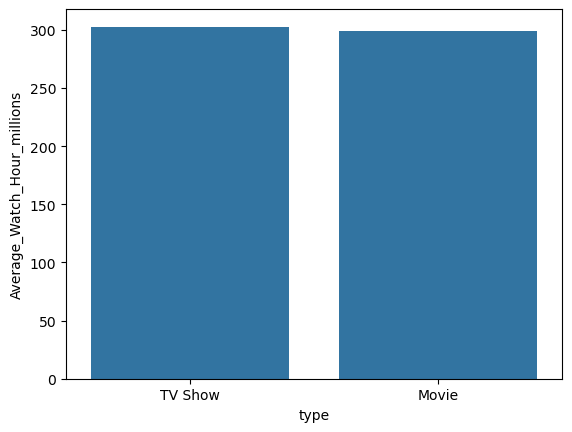

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.barplot(x="type",y="Average_Watch_Hour_millions",data=df)
plt.show

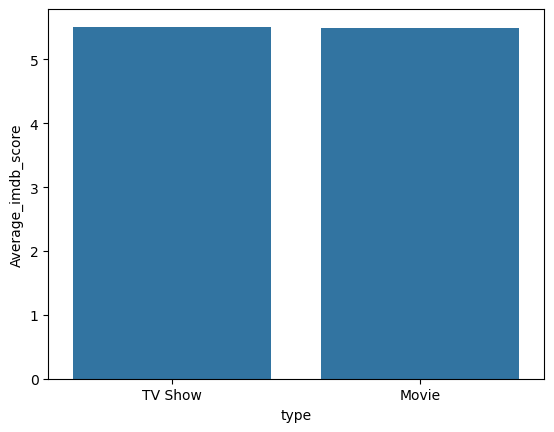

In [34]:
sns.barplot(data=df,x="type",y="Average_imdb_score")
plt.show()

## 7️⃣ Top 10 Genres with Highest Total Views & Average Completion Rate

In [37]:
query="""
select genre, sum(views_millions) as Total_Views,avg(completion_rate) as Average_Completion_Rate
from netflix_titles_clean as t
join netflix_viewership_clean as v
on t.show_id=v.show_id
group by genre
order by Total_Views desc,Average_Completion_Rate desc limit 10;
"""
df=pd.read_sql(query,engine)
df

,genre,Total_Views,Average_Completion_Rate
0,Drama,201924.78,59.403464
1,Action,191783.93,59.792571
2,Comedy,191671.08,60.156077
3,Romance,190769.03,59.219234
4,Sci-Fi,188497.04,59.646212
5,Thriller,187457.81,59.611937
6,Animation,184484.99,59.910606
7,Documentary,183442.16,59.822684
8,Horror,181160.14,60.023643


## 8️⃣ Country with Highest Total Watch Hours

In [38]:
query="""
select t.country,sum(v.watch_hours_millions) as Total_Watch_Hours
from netflix_titles_clean t
join netflix_viewership_clean v
on t.show_id=v.show_id
group by t.country
order by Total_Watch_Hours desc
limit 1;
"""
df=pd.read_sql(query,engine)
df

,country,Total_Watch_Hours
0,France,758592.3


## 9️⃣ Language with Highest Average User Rating & Total Views


In [39]:
query="""
select language,avg(r.rating) as Average_Rating , sum(v.views) as Total_Views
from netflix_titles_clean as t
left join(select show_id,avg(rating) as rating
 from netflix_reviews_clean 
 group by show_id
 )as r
on t.show_id=r.show_id
left join (select show_id,sum(views_millions) as views
from netflix_viewership_clean
group by show_id) as v
on t.show_id=v.show_id
group by t.language
order by Average_Rating desc,Total_Views desc
limit 1
;
"""
df=pd.read_sql(query,engine)
df

,language,Average_Rating,Total_Views
0,Japanese,3.019892,275960.99


## 📊 Customer Behaviour & Quality Analysis

## 🔟 Does Higher IMDb Score Lead to Higher User Ratings and More Watch Hours?

In [7]:
query="""
with review_avg as (
    select 
        show_id,
        avg(rating) as avg_user_rating
    from netflix_reviews_clean
    group by show_id
),

view_data as (
    select 
        show_id,
        sum(watch_hours_millions) as total_watch_hours
    from netflix_viewership_clean
    group by show_id
)

select 
    t.show_id,
    t.imdb_score,
    r.avg_user_rating,
    v.total_watch_hours
from netflix_titles_clean t
left join review_avg r
    on t.show_id = r.show_id
left join view_data v
    on t.show_id = v.show_id
where t.imdb_score is not null;
"""
df=pd.read_sql(query,engine)
df

,show_id,imdb_score,avg_user_rating,total_watch_hours
0,464237c8-d,3.7,2.2,548.46
1,ef1d668f-9,3.2,4.8,237.16
2,61e8d17c-4,8.6,3.9,53.11
3,050cb3d7-4,4.7,2.5,538.07
4,22745f2c-8,8.9,1.5,427.70
...,...,...,...,...
17776,bd617de7-f,6.9,3.8,559.52
17777,fadd6027-4,3.1,2.5,233.70
17778,f382b395-0,9.9,1.1,338.20
17779,b5e4f131-d,6.9,3.6,119.40


<Axes: xlabel='imdb_score', ylabel='total_watch_hours'>

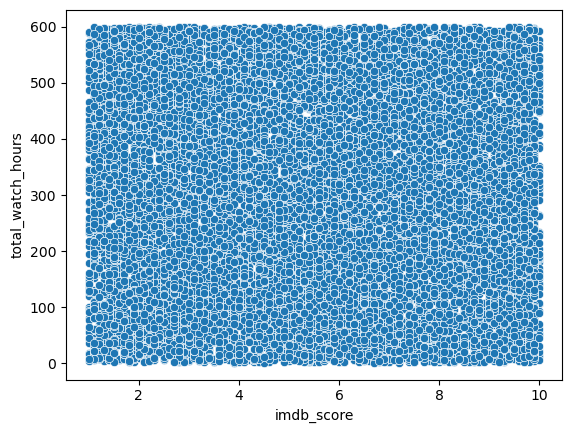

In [9]:
import seaborn as sns
sns.scatterplot(x="imdb_score", y="total_watch_hours", data=df)


<Axes: xlabel='imdb_score', ylabel='avg_user_rating'>

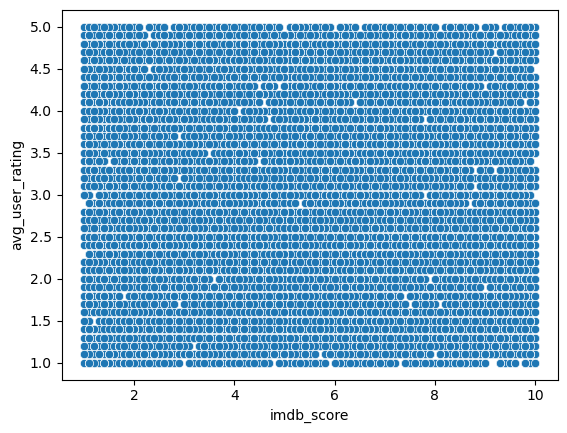

In [10]:
sns.scatterplot(x="imdb_score", y="avg_user_rating", data=df)


## 1️⃣1️⃣ Sentiment Category with Highest Completion Rate


In [11]:
query="""
select r.sentiment,avg(v.Completion_Rate) as Average_Completion_Rate
from netflix_reviews_clean  as r
join (select show_id,avg(completion_rate) as Completion_Rate from netflix_viewership_clean group by show_id ) as v
on r.show_id=v.show_id
group by r.sentiment
order by avg(v.Completion_Rate) desc
limit 1;
"""
df=pd.read_sql(query,engine)
df

,sentiment,Average_Completion_Rate
0,Negative,60.150078


## 1️⃣2️⃣ Top 10 Directors by Average User Rating & Watch Hours

In [12]:
query="""
select t.director,avg(r.Rating) as Average_Rating , sum(v.Watch) as Total_Hours
from netflix_titles_clean as t
join (select show_id,avg(rating) as Rating from netflix_reviews_clean group by show_id) as r
on t.show_id=r.show_id
join (select show_id,sum(watch_hours_millions) as Watch from netflix_viewership_clean group by show_id) as v
on t.show_id=v.show_id
group by t.director
order by Average_Rating desc , Total_Hours desc
limit 10;
"""
df=pd.read_sql(query,engine)
df

,director,Average_Rating,Total_Hours
0,James Navarro,3.606250,4509.10
1,Stephanie Lopez,3.590476,6571.78
2,Jeremy Holmes,3.566667,7551.72
3,George Johnson,3.563636,7138.35
4,Gina Robinson,3.537037,8080.30
5,Pamela Nelson,3.495000,6613.34
6,Shawn Bowen,3.490909,7591.52
7,Patricia Cunningham,3.489286,9840.04
8,William Gilbert,3.477273,5810.23
9,Jonathan Copeland,3.476000,8380.94


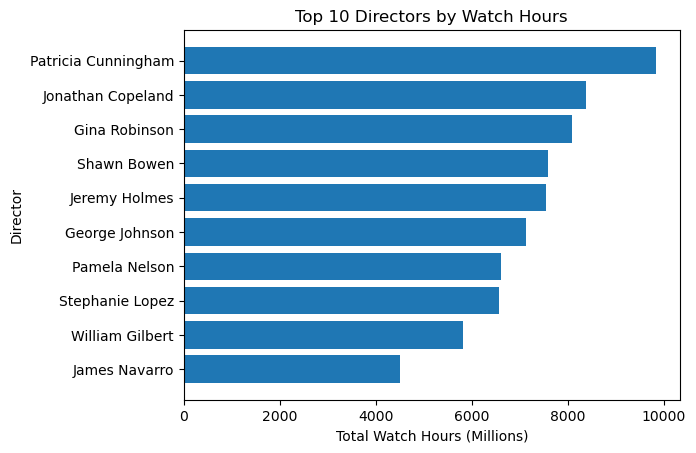

In [15]:
import matplotlib.pyplot as plt

# Assuming df contains your SQL result
# Columns: director, Average_Rating, Total_Watch_Hours

df = df.sort_values("Total_Hours")

plt.figure()
plt.barh(df["director"], df["Total_Hours"])
plt.xlabel("Total Watch Hours (Millions)")
plt.ylabel("Director")
plt.title("Top 10 Directors by Watch Hours")
plt.show()


## 1️⃣3️⃣ Impact of Age Certification on Viewership & Completion Rate

In [17]:
query="""
select t.age_certification,sum(Views)as Total_Views , avg(Completion) as Average_Completion
from netflix_titles_clean as t
join (select show_id,sum(views_millions) as Views , avg(completion_rate) as Completion from netflix_viewership_clean group by show_id) as v
on t.show_id=v.show_id
group by t.age_certification;
"""
df=pd.read_sql(query,engine)
df

,age_certification,Total_Views,Average_Completion
0,Kids,426014.53,60.181782
1,All,419885.35,59.651963
2,Adult,427433.54,59.856545
3,Teen,427857.54,59.228385


## 1️⃣4 Impact of Age Certification on Viewership & Completion Rate

In [18]:
query="""
select s.subscription_type,sum(Revenue) as Total_Revenue, sum(Watch_Hours) as Total_Watch_Hours
from (select show_id,subscription_type,sum(subscription_price) as Revenue from netflix_subscriptions_clean group by show_id,subscription_type) as s
join (select show_id , sum(watch_hours_millions) as Watch_Hours from netflix_viewership_clean group by show_id) as v
on s.show_id=v.show_id
group by s.subscription_type
order by Total_Revenue desc ,Total_Watch_Hours desc
limit 1;
"""
df=pd.read_sql(query,engine)
df

,subscription_type,Total_Revenue,Total_Watch_Hours
0,Premium,86406.83,1873004.12


## 1️⃣5️⃣ Shows That Attract the Most Premium Subscription Users

In [19]:
query="""
select t.title,count(s.subscription_id) as Total_Shows
from netflix_titles_clean t
join netflix_subscriptions_clean as s
on t.show_id=s.show_id
where s.subscription_type="Premium"
group by t.title
order by Total_Shows desc
limit 10
;
"""
df=pd.read_sql(query,engine)
df

,title,Total_Shows
0,Order,5
1,Probably,4
2,Mother,3
3,Push,3
4,Look,3
5,Matter,3
6,Ever,3
7,Own,3
8,Traditional,3
9,True,3


## 1️⃣6️⃣ Shows That Attract the Most Premium Subscription Users

In [20]:
query="""
select v.region,v.device_type,sum(v.watch_hours_millions) as Total_Watch_Hours 
from netflix_viewership_clean as v
group by v.region,v.device_type
order by Total_Watch_Hours desc 
limit 1;"""
df=pd.read_sql(query,engine)
df

,region,device_type,Total_Watch_Hours
0,South America,Laptop,371491.88


## 1️⃣7️⃣ Do Newly Added Shows Receive Higher Watch Hours?


In [21]:
query="""
-- 17.Do newly added shows receive higher watch hours compared to older ones?
select 
    year(t.date_added) as Year_Added,
    round(sum(v.watch_hours_millions),2) as Total_Watch_Hours
from netflix_titles_clean t
join netflix_viewership_clean v
    on t.show_id = v.show_id
group by year(t.date_added)
order by Year_Added;
"""
df=pd.read_sql(query,engine)
df

,Year_Added,Total_Watch_Hours
0,2018,564346.38
1,2019,659977.73
2,2020,621041.95
3,2021,641105.82
4,2022,631900.50
5,2023,666389.25
6,2024,650824.10
7,2025,634419.26
8,2026,69425.04


<Axes: xlabel='Year_Added', ylabel='Total_Watch_Hours'>

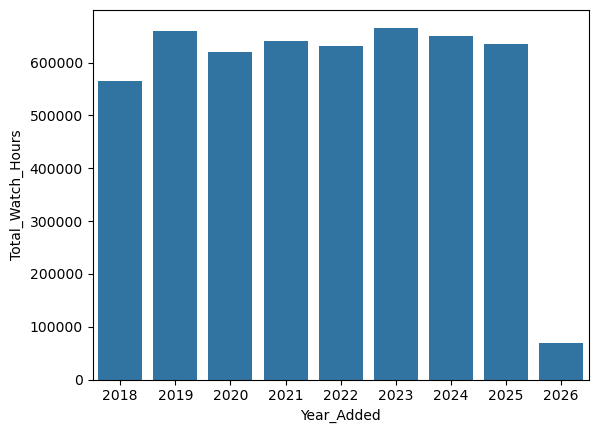

In [23]:
sns.barplot(df,x="Year_Added",y="Total_Watch_Hours")

## 1️⃣8️⃣ Which Genre Gives the Highest Return on Investment (ROI)?


In [24]:
query="""
select t.genre,(sum(watch_hours_millions) / sum(budget_millions)) as ROI
from netflix_titles_clean as t
join netflix_viewership_clean  as v
on t.show_id=v.show_id
group by t.genre
order by ROI desc
limit 1;
"""
df=pd.read_sql(query,engine)
df

,genre,ROI
0,Romance,2.054394


## 1️⃣9️⃣ Which Content Rating Generates the Highest Engagement?

In [25]:
query="""
-- 19. Which content rating generates highest engagement?

select 
    t.rating,
    round(avg(v.Watch_Hours),2) as Avg_Watch_Hours
from netflix_titles_clean t
join (
    select show_id, sum(watch_hours_millions) as Watch_Hours
    from netflix_viewership_clean
    group by show_id
) v
on t.show_id = v.show_id
group by t.rating
order by Avg_Watch_Hours desc
limit 1;
"""
df=pd.read_sql(query,engine)
df

,rating,Avg_Watch_Hours
0,G,305.54


## 2️⃣0️⃣ Build Overall Performance Score for Each Show

In [6]:
query="""
SELECT 
    t.show_id,
    t.imdb_score AS IMDB_Score,
    r.rating AS Avg_User_Rating,
    s.price AS Total_Subscription_Price,
    v.watch_hours AS Total_Watch_Hours,
    v.completion AS Avg_Completion_Rate
FROM netflix_titles_clean AS t

LEFT JOIN (
    SELECT show_id, AVG(rating) AS rating
    FROM netflix_reviews_clean
    GROUP BY show_id
) AS r ON t.show_id = r.show_id

LEFT JOIN (
    SELECT show_id, SUM(subscription_price) AS price
    FROM netflix_subscriptions_clean
    GROUP BY show_id
) AS s ON t.show_id = s.show_id

LEFT JOIN (
    SELECT 
        show_id,
        SUM(watch_hours_millions) AS watch_hours,
        AVG(completion_rate) AS completion
    FROM netflix_viewership_clean
    GROUP BY show_id
) AS v ON t.show_id = v.show_id;
"""
df=pd.read_sql(query,engine)
df

,show_id,IMDB_Score,Avg_User_Rating,Total_Subscription_Price,Total_Watch_Hours,Avg_Completion_Rate
0,464237c8-d,3.7,2.2,4.08,548.46,79.96
1,ef1d668f-9,3.2,4.8,23.16,237.16,71.75
2,61e8d17c-4,8.6,3.9,8.25,53.11,46.23
3,050cb3d7-4,4.7,2.5,12.48,538.07,58.06
4,22745f2c-8,8.9,1.5,18.95,427.70,83.52
...,...,...,...,...,...,...
17776,bd617de7-f,6.9,3.8,19.88,559.52,71.79
17777,fadd6027-4,3.1,2.5,11.59,233.70,91.53
17778,f382b395-0,9.9,1.1,15.20,338.20,83.68
17779,b5e4f131-d,6.9,3.6,15.28,119.40,38.01
